In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-ct/demos/demo2.png
/kaggle/input/brain-ct/demos/demo3.png
/kaggle/input/brain-ct/demos/demo.jpg
/kaggle/input/brain-ct/demos/demo4.png
/kaggle/input/brain-ct/brain_CT_sinograms/56 (32).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/101 (24).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/116 (16).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/56 (2).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/106 (10).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/64 (1).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/96 (1) - Copy - Copy.jpg
/kaggle/input/brain-ct/brain_CT_sinograms/61 (22).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/98 (29) - Copy - Copy.jpg
/kaggle/input/brain-ct/brain_CT_sinograms/55 (32).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/50 (7).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/64 (17).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/126 (28).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/120 (23).jpg
/kaggle/input/brain-ct/brain_CT_sinograms/108 (25).jpg
/kagg

# Loading the Dataset

In [2]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

2025-06-20 15:35:14.556556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750433714.757458      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750433714.815241      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Paths
input_dir = '/kaggle/input/brain-ct/brain_CT_sinograms'
output_dir = '/kaggle/input/brain-ct/brain_CT'

# Get sorted file names (to ensure matching)
input_files = sorted(os.listdir(input_dir))
output_files = sorted(os.listdir(output_dir))

In [4]:
# Initialize lists
x_data = []
y_data = []

# Load images
for in_file, out_file in zip(input_files, output_files):
    # Load grayscale image and resize to (256, 256)
    input_img = load_img(os.path.join(input_dir, in_file), color_mode='grayscale', target_size=(256, 256))
    output_img = load_img(os.path.join(output_dir, out_file), color_mode='grayscale', target_size=(256, 256))
    
    # Convert to array and normalize to [0, 1]
    x = img_to_array(input_img) / 255.0
    y = img_to_array(output_img) / 255.0

    x_data.append(x)
    y_data.append(y)

# Convert to NumPy arrays
x_data = np.array(x_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.float32)

print("Input shape:", x_data.shape)   # (125, 256, 256, 1)
print("Output shape:", y_data.shape)  # (125, 256, 256, 1)

Input shape: (125, 256, 256, 1)
Output shape: (125, 256, 256, 1)


In [5]:
x_train = x_data[:100]
x_test = x_data[100:]
y_train = y_data[:100]
y_test = y_data[100:]

In [6]:
from tensorflow.keras import layers, models

# ----- Custom Loss: MSE + SSIM -----
def mse_ssim_loss(y_true, y_pred, ssim_weight=0.1):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)
    ssim_loss = tf.reduce_mean(1.0 - ssim)
    return mse + ssim_weight * ssim_loss

# Model

In [7]:
# ----- Simple CNN Model for Image Reconstruction -----
def build_model(input_shape=(256, 256, 1)):
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(inputs)
    x = layers.Conv2D(64, (3, 3), padding="same", activation='relu')(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation='relu')(x)
    outputs = layers.Conv2D(1, (3, 3), padding="same", activation='sigmoid')(x)

    return models.Model(inputs, outputs)

In [8]:
model = build_model()

# ----- Compile with Custom Loss -----
model.compile(
    optimizer='adam',
    loss=lambda y_true, y_pred: mse_ssim_loss(y_true, y_pred, ssim_weight=1),
    metrics=['mse']
)

I0000 00:00:1750433729.259204      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750433729.259916      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
# ----- Train the Model -----
model.fit(x_train, y_train, epochs=30, batch_size=8)

Epoch 1/30


I0000 00:00:1750433733.399175      63 service.cc:148] XLA service 0x7f7208029e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750433733.399671      63 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750433733.399706      63 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1750433733.575047      63 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert/Assert
W0000 00:00:1750433733.575808      63 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert_1/Assert
W0000 00:00:1750433733.576480      63 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert_2/Assert
W0000 00:00:1750433733.576920      63 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert_3/Assert
I0000 00:00:1750433733.720479      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/13 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.1046 - mse: 0.1926

I0000 00:00:1750433739.663904      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1.0915 - mse: 0.1807

W0000 00:00:1750433740.247341      60 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert/Assert
W0000 00:00:1750433740.247584      60 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert_1/Assert
W0000 00:00:1750433740.247983      60 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert_2/Assert
W0000 00:00:1750433740.248167      60 assert_op.cc:38] Ignoring Assert operator compile_loss/lambda/SSIM/Assert_3/Assert


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 335ms/step - loss: 1.0886 - mse: 0.1778
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 1.0355 - mse: 0.1325
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.9194 - mse: 0.0978
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.7179 - mse: 0.1276
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6300 - mse: 0.1474
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.6369 - mse: 0.1480
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6183 - mse: 0.1452
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6270 - mse: 0.1447
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6216 - mse: 0.1447
Epoch 10/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6236 - mse: 0.1463
Epoch 11/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6214 - mse: 0.1443
Epoch 12/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6242 - mse: 0.1445
Epoch 13/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms

# Evaluation

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def predict_and_plot(model, x_data, y_data, index=0):
    # Select one sample
    input_img = x_data[index]         # shape: (256, 256, 1)
    ground_truth = y_data[index]      # shape: (256, 256, 1)


    # Predict
    prediction = model.predict(input_img)  # shape: (256, 256, 1)

    # Remove last channel dimension for plotting
    input_img_plot = input_img[:, :, 0]
    prediction_plot = prediction[:, :, 0]
    ground_truth_plot = ground_truth[:, :, 0]

    # Plot all
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(input_img_plot, cmap='gray')
    plt.title('Input')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(prediction_plot, cmap='gray')
    plt.title('Predicted Output')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(ground_truth_plot, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


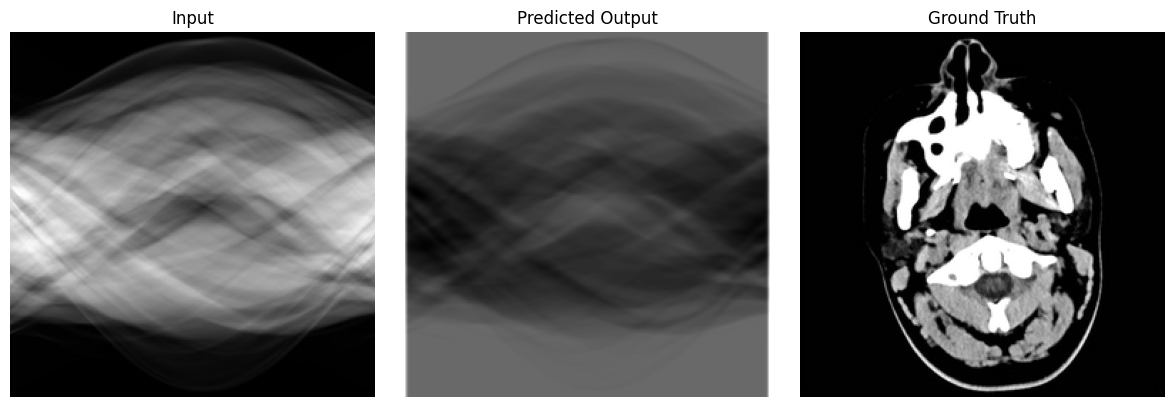

In [11]:
predict_and_plot(model, x_data, y_data, index=0)  # change index to test different images
